# 1. Load and Clean Dataset

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"datasets\car_prediction_data.csv")

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Create car age feature
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

# Drop unnecessary columns
df = df.drop(["Car_Name", "Year"], axis=1)

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'datasets\\car_prediction_data.csv'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R² Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R² Score: 0.4403474295518832
MAE: 1.5615683333333332


In [ ]:
import joblib
joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

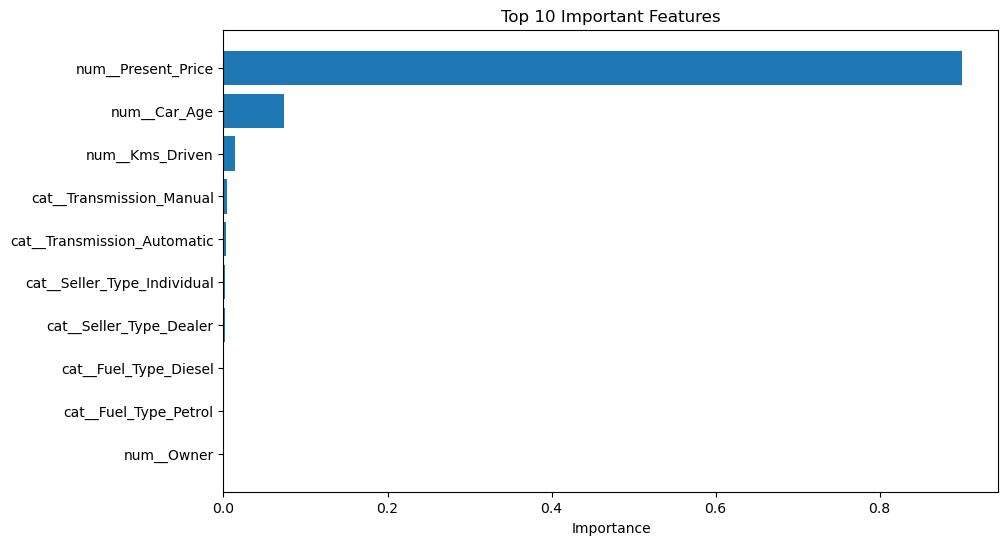

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = model.named_steps[
    "regressor"
].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()